In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

data_frame = pd.read_excel("C:/Users/mdrud/mlops_projects/mlops_recommendation_sysytem/data/raw/online_course_recommendation_v2.xlsx", sheet_name = "Sheet1")

df = data_frame.copy()

In [2]:
df.head(3)

,user_id,course_id,course_name,instructor,course_duration_hours,certification_offered,difficulty_level,rating,enrollment_numbers,course_price,feedback_score,study_material_available,time_spent_hours,previous_courses_taken
0,15796,9366,Python for Beginners,Emma Harris,39.1,Yes,Beginner,5.0,21600,317.50,0.797,Yes,17.60,4
1,861,1928,Cybersecurity for Professionals,Alexander Young,36.3,Yes,Beginner,4.3,15379,40.99,0.770,Yes,28.97,9
2,38159,9541,DevOps and Continuous Deployment,Dr. Mia Walker,13.4,Yes,Beginner,3.9,6431,380.81,0.772,Yes,52.44,4


## Understanding Data

In [3]:
#Using certain method to understand data properly
print("<------------Information About the Data--------->")
print(df.info())

print("<------------Decribing numerical variables--------->")
print(df.describe())

print("<------------Describing both numerical and categorical variables--------->")
print(df.describe(include="all"))

print("<------------Checking potential null values--------->")
print(df.isnull().sum())

<------------Information About the Data--------->
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   user_id                   100000 non-null  int64  
 1   course_id                 100000 non-null  int64  
 2   course_name               100000 non-null  object 
 3   instructor                100000 non-null  object 
 4   course_duration_hours     100000 non-null  float64
 5   certification_offered     100000 non-null  object 
 6   difficulty_level          100000 non-null  object 
 7   rating                    100000 non-null  float64
 8   enrollment_numbers        100000 non-null  int64  
 9   course_price              100000 non-null  float64
 10  feedback_score            100000 non-null  float64
 11  study_material_available  100000 non-null  object 
 12  time_spent_hours          100000 non-null  float64


## EDA(Exploratory Data Analysis):

### Univariate Analysis: (Considering one variable/feature)
#### Exploring Categorical Feature Distribution

In [4]:
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
categorical_cols

['course_name',
 'instructor',
 'certification_offered',
 'difficulty_level',
 'study_material_available']

In [5]:
def count_plot(name):
    plt.figure(figsize=(10,4))
    sns.countplot(data=df, x=name, hue=name, palette="viridis", legend=True)
    plt.title(f"Distribution of {name}")
    plt.show()

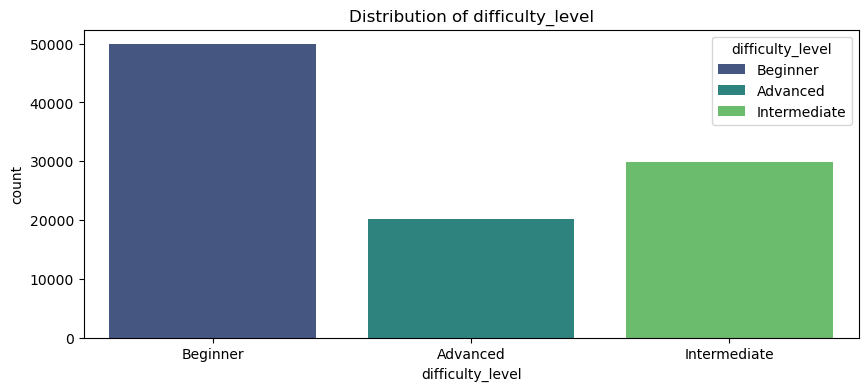

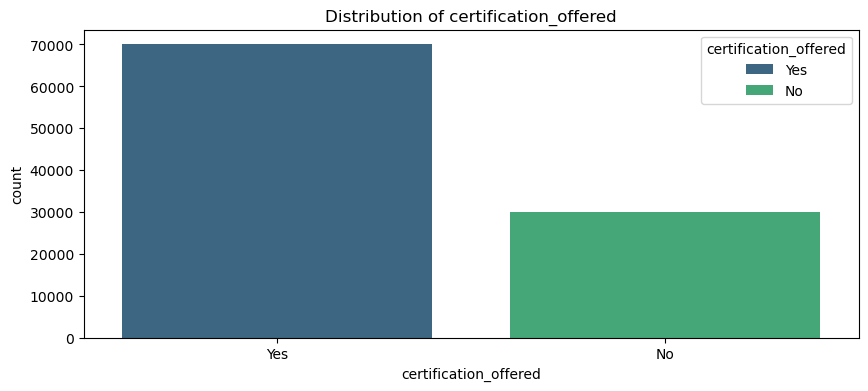

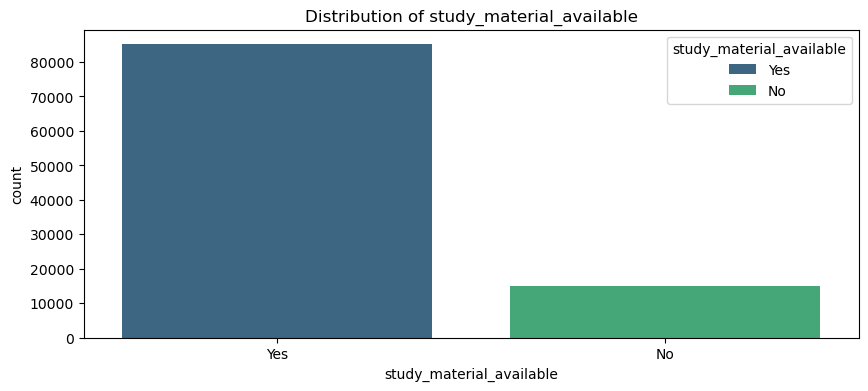

In [19]:
for x in ['difficulty_level','certification_offered','study_material_available']:
    count_plot(x)

#### Analyzing Numerical Feature Distribution

In [6]:
numerical_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
numerical_cols

['user_id',
 'course_id',
 'course_duration_hours',
 'rating',
 'enrollment_numbers',
 'course_price',
 'feedback_score',
 'time_spent_hours',
 'previous_courses_taken']

In [7]:
num_cols = [x for x in numerical_cols if x not in ["user_id","course_id"]]
num_cols

['course_duration_hours',
 'rating',
 'enrollment_numbers',
 'course_price',
 'feedback_score',
 'time_spent_hours',
 'previous_courses_taken']

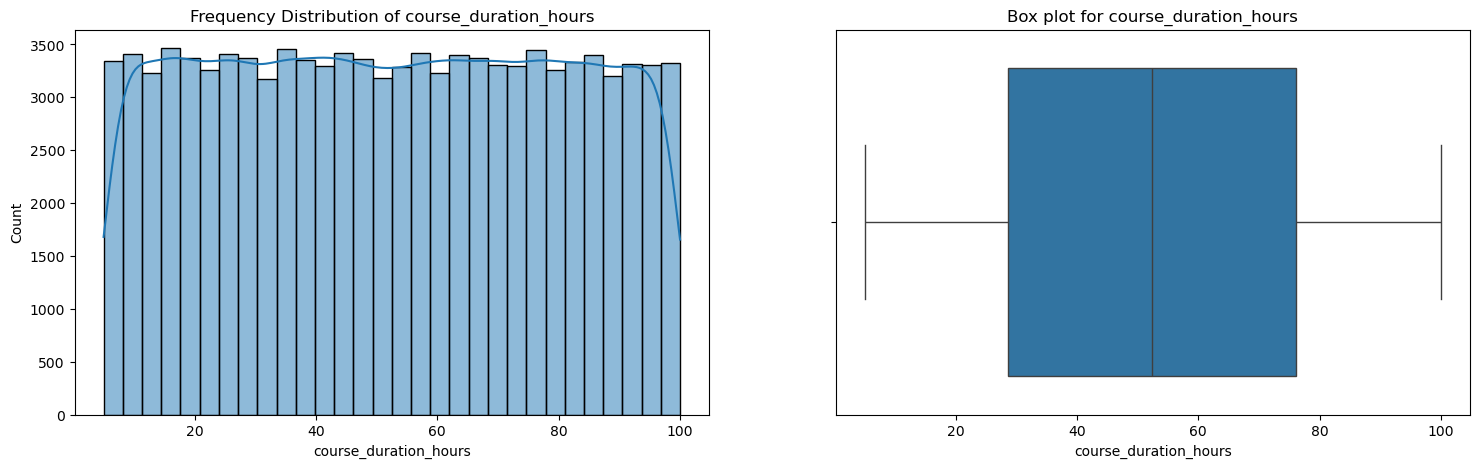

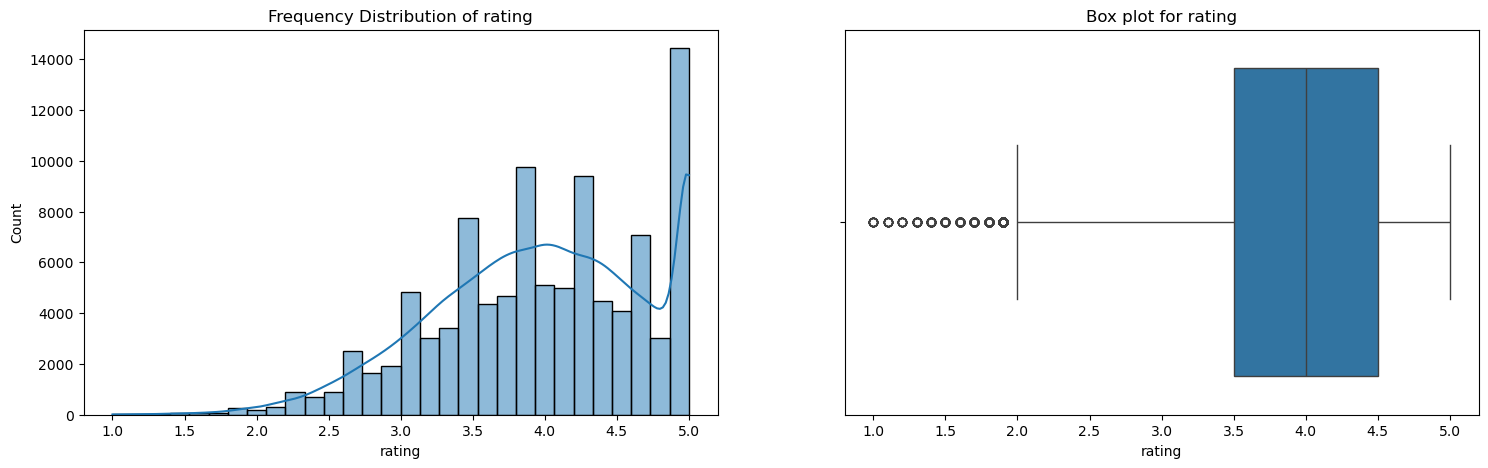

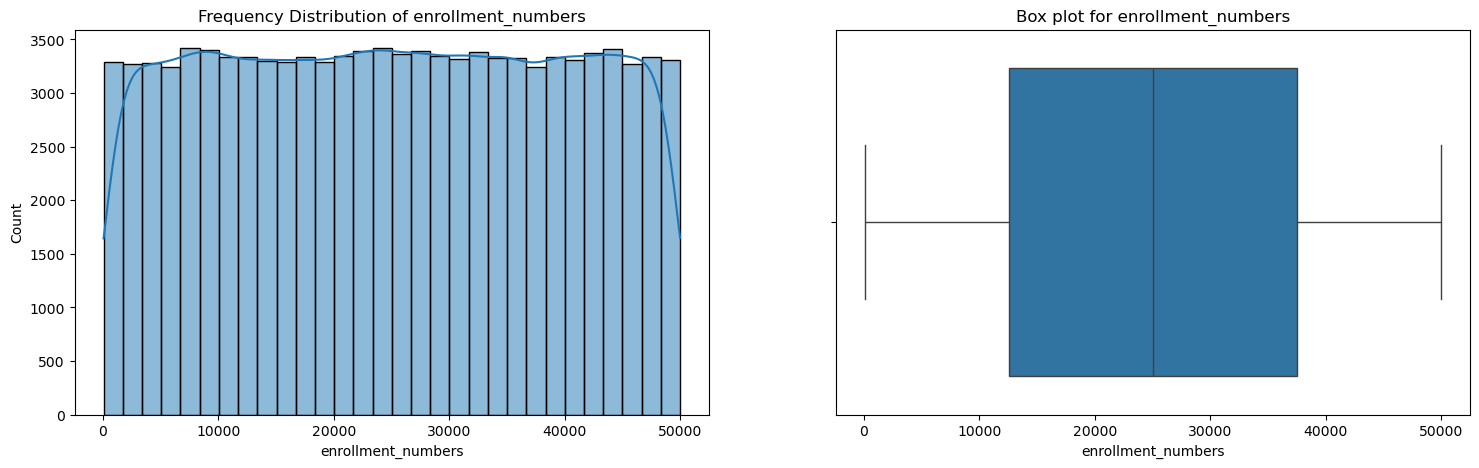

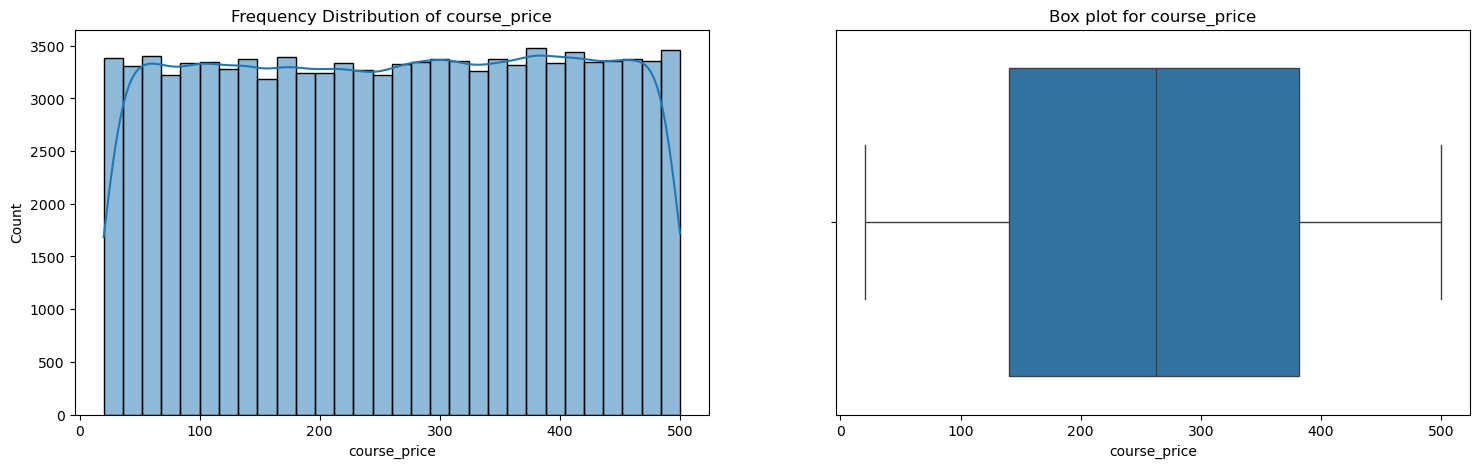

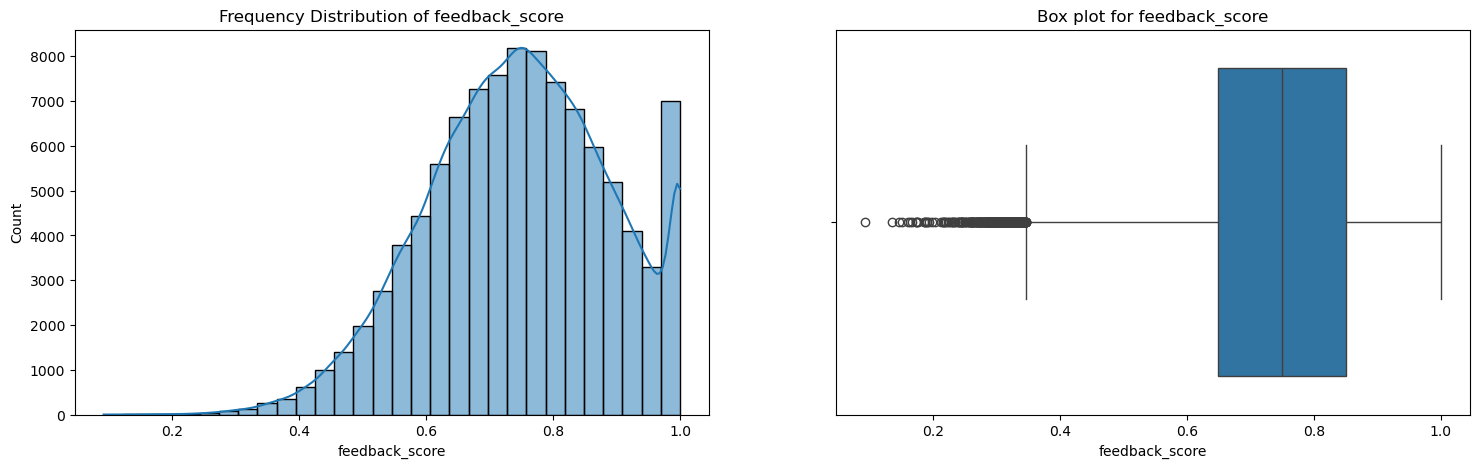

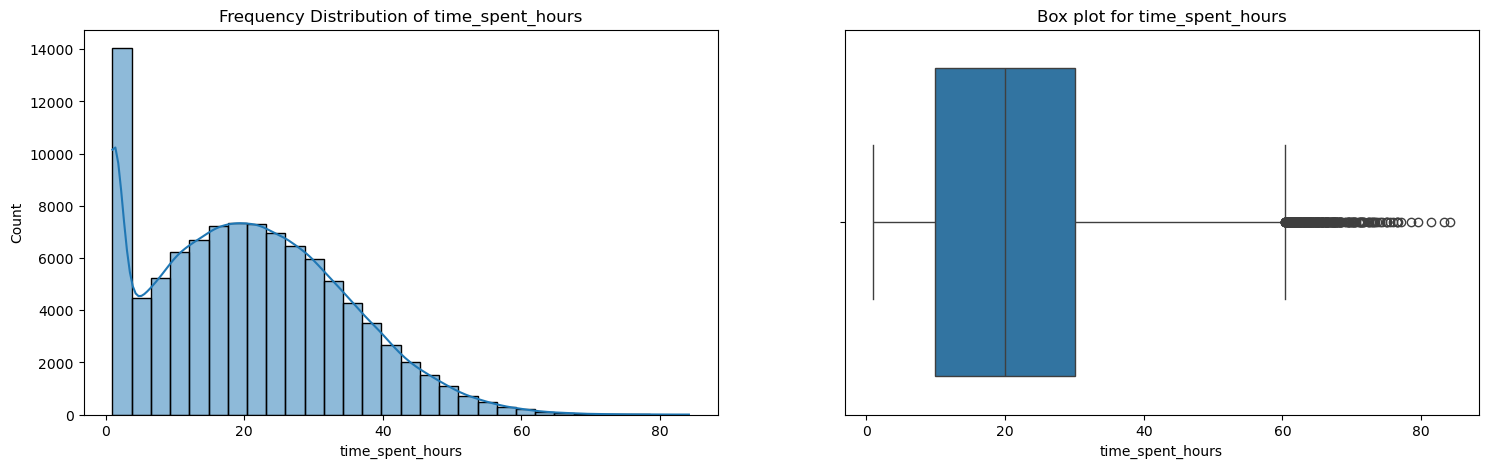

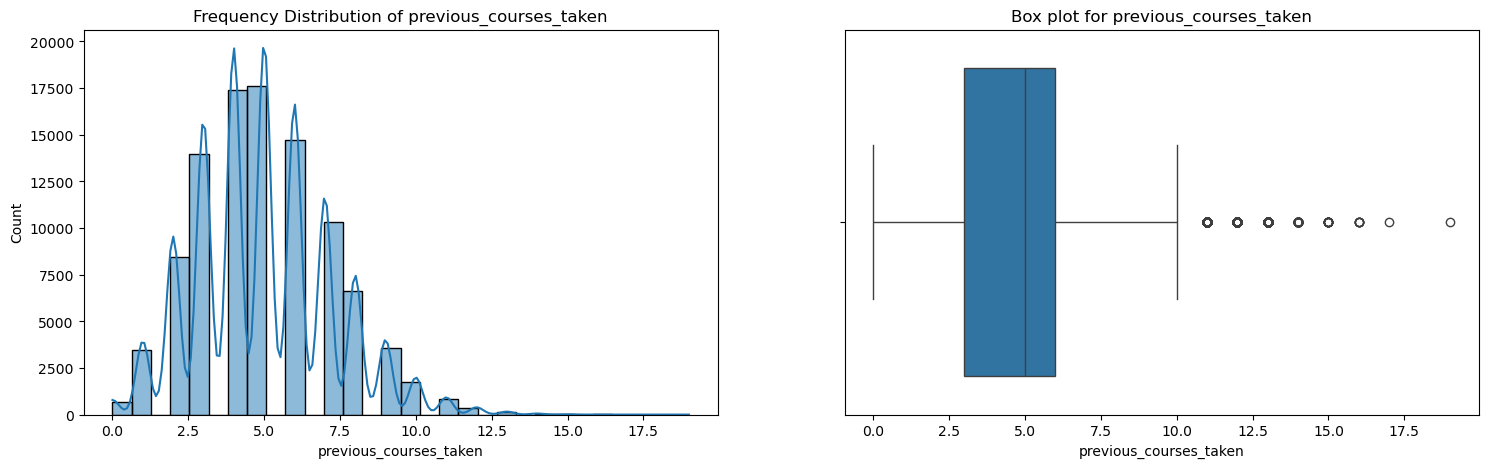

In [22]:
for col in num_cols:
    plt.figure(figsize=(18,5))

    plt.subplot(1,2,1)
    sns.histplot(data=df, x = col, kde=True, bins=30)
    plt.title(f"Frequency Distribution of {col}")

    plt.subplot(1,2,2)
    sns.boxplot(data=df, x=col)
    plt.title(f"Box plot for {col}")

    plt.show()

## Identifying top courses and instructors in different different aspects

In [ ]:
# Identifying the top 10 courses by enrollment numbers
top_courses_enrollment = df.groupby("course_name")["enrollment_numbers"].sum().nlargest(10)
plt.figure(figsize=(12, 7))
sns.barplot(x=top_courses_enrollment.values, y=top_courses_enrollment.index, hue=top_courses_enrollment.index, palette='crest', legend=False)
plt.title('Top 10 Courses by Enrollment Numbers')
plt.xlabel('Total Enrollment Numbers')
plt.ylabel('Course Name')
plt.show()

print("\n")
# Identifying the top 10 courses by rating
top_courses_rating = df.groupby('course_name')['rating'].mean().nlargest(10)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_courses_rating.values, y=top_courses_rating.index, hue=top_courses_rating.index, palette='magma', legend=False)
plt.title('Top 10 Courses by Average Rating')
plt.xlabel('Average Rating')
plt.ylabel('Course Name')
plt.show()

print("\n")
# Identifying the top 10 instructors by the number of courses offered
top_instructors_courses = df.groupby('instructor')['course_name'].nunique().nlargest(10)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_instructors_courses.values, y=top_instructors_courses.index, hue=top_instructors_courses.index, palette='viridis', legend=False)
plt.title('Top 10 Instructors by Number of Courses Offered')
plt.xlabel('Number of Courses Offered')
plt.ylabel('Instructor Name')
plt.show()

print("\n")
# Identifying the top 10 instructors by average rating
top_instructors_avg_rating = df.groupby('instructor')['rating'].mean().nlargest(10)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_instructors_avg_rating.values, y=top_instructors_avg_rating.index, hue=top_instructors_avg_rating.index, palette='magma', legend=False)
plt.title('Top 10 Instructors by Average Rating')
plt.xlabel('Average Rating')
plt.ylabel('Instructor Name')
plt.show()

### Bivariate Data Analysis:(Considering two numerical colums)

In [ ]:
for i, col1 in enumerate(num_cols):
    for col2 in num_cols[i+1:len(num_cols)]:
        plt.figure(figsize=(9,5))
        sns.scatterplot(x=col1, y=col2,data=df)
        plt.title(f"Scatter plot between {col1} and {col2}")
        plt.show()
        print("\n")

In [ ]:
sns.pairplot(df[num_cols])

In [8]:
numerical_df = df[num_cols]
numerical_df

,course_duration_hours,rating,enrollment_numbers,course_price,feedback_score,time_spent_hours,previous_courses_taken
0,39.1,5.0,21600,317.50,0.797,17.60,4
1,36.3,4.3,15379,40.99,0.770,28.97,9
2,13.4,3.9,6431,380.81,0.772,52.44,4
3,58.3,3.1,48245,342.80,0.969,22.29,6
4,30.8,2.8,34556,381.01,0.555,22.01,5
...,...,...,...,...,...,...,...
99995,17.3,3.9,49101,485.34,0.838,16.35,3
99996,68.4,3.5,35107,162.80,0.922,41.94,7
99997,73.8,4.3,12146,24.02,0.990,15.87,5
99998,30.3,3.5,9933,402.24,0.630,21.05,4


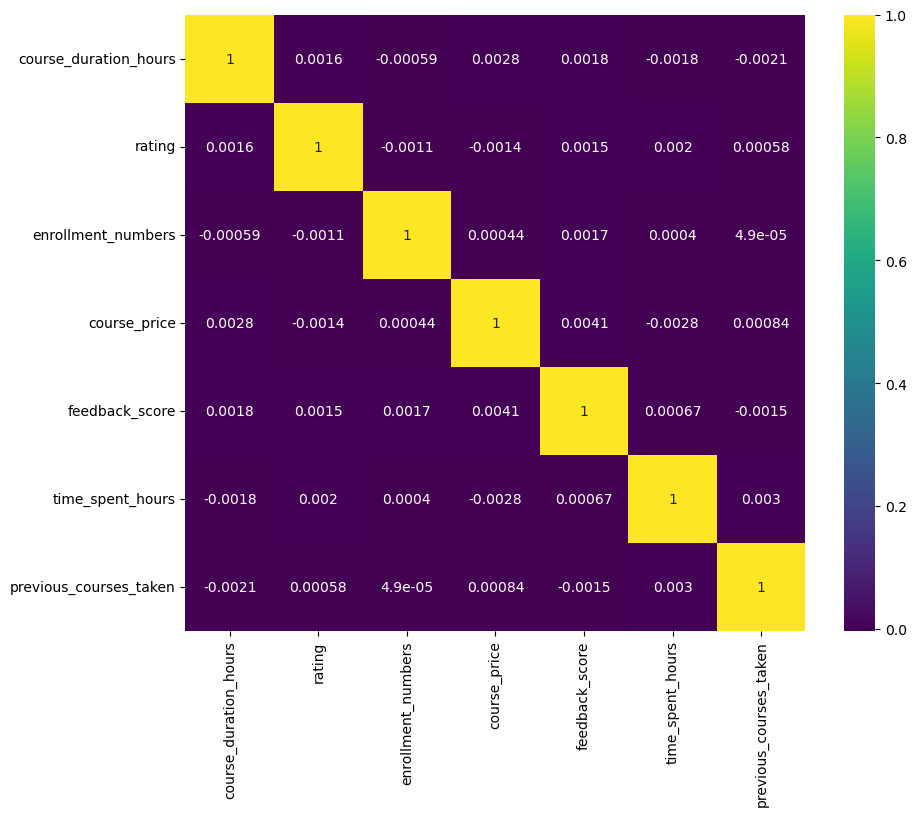

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(numerical_df.corr(),cmap="viridis",annot=True)
plt.show()

In [9]:
# Outlier detection and clipping outliers
outlier_summary = {}
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - IQR*1.5
    upper_limit = Q3 + IQR*1.5
    outliers = (df[col] > upper_limit) | (df[col] < lower_limit)
    outlier_summary[col] = outliers.sum().item()
    df[col] = df[col].clip(lower=lower_limit, upper=upper_limit)

    

for key,value in outlier_summary.items():
    print(key, ":", value)

course_duration_hours : 0
rating : 529
enrollment_numbers : 0
course_price : 0
feedback_score : 377
time_spent_hours : 342
previous_courses_taken : 1373


In [10]:
outlier_summary_checking = {}
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - IQR*1.5
    upper_limit = Q3 + IQR*1.5
    outliers = (df[col] > upper_limit) | (df[col] < lower_limit)
    outlier_summary_checking[col] = outliers.sum().item()

for key,value in outlier_summary_checking.items():
    print(key, ":", value)

course_duration_hours : 0
rating : 0
enrollment_numbers : 0
course_price : 0
feedback_score : 0
time_spent_hours : 0
previous_courses_taken : 0


## Preparing data for the recommendation sysytem :

In [11]:
df["course_name"].unique()

array(['Python for Beginners', 'Cybersecurity for Professionals',
       'DevOps and Continuous Deployment',
       'Project Management Fundamentals', 'Ethical Hacking Masterclass',
       'Networking and System Administration',
       'Personal Finance and Wealth Building',
       'Blockchain and Decentralized Applications',
       'Graphic Design with Canva', 'Fitness and Nutrition Coaching',
       'Public Speaking Mastery', 'Photography and Video Editing',
       'Advanced Machine Learning', 'Game Development with Unity',
       'Cloud Computing Essentials', 'Mobile App Development with Swift',
       'Data Visualization with Tableau',
       'Stock Market and Trading Strategies',
       'Fundamentals of Digital Marketing', 'AI for Business Leaders'],
      dtype=object)

In [12]:
num_cols.remove('rating')

In [13]:
num_cols

['course_duration_hours',
 'enrollment_numbers',
 'course_price',
 'feedback_score',
 'time_spent_hours',
 'previous_courses_taken']

In [14]:
# Extracting the categorical variable from the dataset so that we can apply the encoding techinique easily
cate_cols  = df.select_dtypes(include=['object']).columns.tolist()
cate_cols

['course_name',
 'instructor',
 'certification_offered',
 'difficulty_level',
 'study_material_available']

In [15]:
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df, test_size = 0.20, random_state= 42, shuffle=True)


In [16]:
feature_cols = [col for col in df.columns if col not in ['user_id','course_id','rating']]

In [17]:
feature_cols

['course_name',
 'instructor',
 'course_duration_hours',
 'certification_offered',
 'difficulty_level',
 'enrollment_numbers',
 'course_price',
 'feedback_score',
 'study_material_available',
 'time_spent_hours',
 'previous_courses_taken']

In [18]:
user_col = "user_id"
item_col = "course_id"
rating_col = "rating"

min_rating = df[rating_col].min()
max_rating = df[rating_col].max()

## Model Building:
### Colaborative Filtering Model:

In [20]:
from sklearn.decomposition import TruncatedSVD
import numpy as np

pivot = train_df.pivot_table(
    index="user_id",
    columns="course_id",
    values="rating"
)

# Fill temporarily with user mean (better than 0)
user_means = pivot.mean(axis=1)
pivot_centered = pivot.sub(user_means, axis=0).fillna(0)

# SVD on centered matrix
svd = TruncatedSVD(n_components=50, random_state=42)
latent = svd.fit_transform(pivot_centered)

reconstructed = np.dot(latent, svd.components_)

# Add user means back
pred_matrix = pd.DataFrame(
    reconstructed,
    index=pivot.index,
    columns=pivot.columns
).add(user_means, axis=0)


### Creating evaluation function (shared across CF, CBF, Hybrid) :

In [30]:
def evaluate_model(pred_matrix, test_df):
    mask = test_df["user_id"].isin(pred_matrix.index) & \
           test_df["course_id"].isin(pred_matrix.columns)

    eval_df = test_df[mask].copy()

    eval_df["pred"] = pred_matrix.to_numpy()[
        pred_matrix.index.get_indexer(eval_df["user_id"]),
        pred_matrix.columns.get_indexer(eval_df["course_id"])
    ]

    from sklearn.metrics import mean_squared_error, mean_absolute_error

    rmse = mean_squared_error(eval_df["rating"], eval_df["pred"])
    mae  = mean_absolute_error(eval_df["rating"], eval_df["pred"])

    return rmse, mae


In [31]:
evaluate_model(pred_matrix,test_df)

(0.8774804386258467, 0.7532598649918664)

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cate", OneHotEncoder(handle_unknown="ignore"), cate_cols)
    ]
)

X_train = preprocessor.fit_transform(train_df[feature_cols])
X_test  = preprocessor.transform(test_df[feature_cols])

y_train = train_df[rating_col].values
y_test  = test_df[rating_col].values

In [23]:
X_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 880000 stored elements and shape (80000, 53)>

### Implementing the Content Based Filtering(CBF) using the RandomForest:

In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline



from sklearn.ensemble import RandomForestRegressor

cbf_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

cbf_model.fit(X_train, y_train)

,n_estimators,150
,criterion,'squared_error'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

cbf_preds = cbf_model.predict(X_test)

cbf_rmse = mean_squared_error(y_test, cbf_preds)
cbf_mae  = mean_absolute_error(y_test, cbf_preds)

print("CBF RMSE:", cbf_rmse)
print("CBF MAE :", cbf_mae)


CBF RMSE: 0.5348625576263325
CBF MAE : 0.6027235834560821


In [32]:
cbf_pred_matrix = test_df.copy()
cbf_pred_matrix["pred"] = cbf_preds

In [33]:
cbf_pred_matrix.head(5)

,user_id,course_id,course_name,instructor,course_duration_hours,certification_offered,difficulty_level,rating,enrollment_numbers,course_price,feedback_score,study_material_available,time_spent_hours,previous_courses_taken,pred
75721,24215,4150,Python for Beginners,Isabella Scott,49.0,Yes,Intermediate,4.5,27405,467.73,0.808,Yes,30.87,3.0,3.966490
80184,499,3711,Blockchain and Decentralized Applications,Ethan Hall,82.0,No,Intermediate,3.4,28053,204.25,0.579,Yes,1.00,3.0,3.954730
19864,1580,33,Python for Beginners,Michael Brown,49.2,Yes,Advanced,3.1,42718,465.76,0.885,Yes,16.85,2.0,3.946292
76699,33324,1665,Networking and System Administration,Benjamin Lewis,13.1,Yes,Beginner,4.5,22922,480.99,0.589,Yes,38.63,5.0,3.951636
92991,29703,4540,Data Visualization with Tableau,James Clark,27.4,Yes,Beginner,3.5,20921,277.85,0.700,Yes,16.05,6.0,3.983621


### Building Content-Based (Cosine Similarity) Model:

In [ ]:
import pandas as pd

X_train_df = pd.DataFrame(X_train.toarray(), index=train_df["course_id"])

course_vectors = X_train_df.groupby(level=0).mean()

course_vectors.head()


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity


K = 30  # keep top 30 similar items

sim_full = cosine_similarity(course_vectors)
sim_df   = pd.DataFrame(sim_full, index=course_vectors.index, columns=course_vectors.index)

# Sparse Top-K
for col in sim_df.columns:
    top_k = sim_df[col].nlargest(K+1).index
    sim_df[col] = sim_df[col].where(sim_df[col].index.isin(top_k), 0.0)

cos_sim_matrix = sim_df
print("Cosine similarity CBF model ready")


In [ ]:
def recommend_courses(course_id, top_n=5):
    if course_id not in cos_sim_matrix.index:
        return f"Course {course_id} not found in data"

    sims = cos_sim_matrix.loc[course_id].sort_values(ascending=False)

    # remove the course itself and return top-N
    return sims.iloc[1:top_n+1].index.tolist()  


In [ ]:
recommend_courses(101, top_n=5)

In [ ]:
def cosine_predict(user_id, course_id):
    
    
    if user_id not in train_pivot.index or course_id not in cos_sim_matrix.columns:
        return np.nan

    rated_items = train_pivot.loc[user_id].dropna()
    if rated_items.empty:
        return np.nan
    
    sims = cos_sim_matrix.loc[course_id, rated_items.index]

    top_k = sims.nlargest(30)        # same K for consistency
    ratings = rated_items[top_k.index]

    return np.dot(top_k, ratings) / (top_k.abs().sum() + 1e-8)


In [ ]:
test_df["cosine_cbf_pred"] = test_df.apply(
        lambda row: cosine_predict(row.user_id, row.course_id), axis=1
)

print(test_df.head())

### Hybrid Model (CF + Cosine-CBF):

In [ ]:
def hybrid_predict(cf, cbf, alpha):
    return alpha * cf + (1 - alpha) * cbf

In [ ]:
test_df["cf_pred"] = test_df.apply(lambda r: pred_matrix.loc[r.user_id, r.course_id]
                                   if r.user_id in pred_matrix.index and r.course_id in pred_matrix.columns else np.nan, axis=1)

test_df["cbf_pred"] = test_df.apply(lambda r: cosine_predict(r.user_id, r.course_id), axis=1)

#### Evaluating with multiple alpha values and chossing the best one:

In [ ]:
test_df["cf_pred"]  = test_df["cf_pred"].fillna(test_df["cf_pred"].mean())
test_df["cbf_pred"] = test_df["cbf_pred"].fillna(test_df["cbf_pred"].mean())


In [ ]:

alphas = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]

results = {}

for a in alphas:
    test_df[f"hybrid_{a}"] = hybrid_predict(test_df["cf_pred"], test_df["cbf_pred"], a)

    from sklearn.metrics import mean_squared_error
    rmse = mean_squared_error(test_df["rating"], test_df[f"hybrid_{a}"])

    results[a] = rmse
    print(f"Alpha={a} → RMSE={rmse}")

In [ ]:
best_alpha = min(results, key=results.get)
print("\nBest alpha =", best_alpha, "with RMSE =", results[best_alpha])

### Final RandomForest CBF Model for the deployment:(Trianing with whole data set)

In [ ]:
user_features_df = df.groupby('user_id')[[
    'rating',
    'course_duration_hours',
    'course_price',
    'feedback_score',
    'time_spent_hours',
    'previous_courses_taken'
]].mean()

user_features_df.columns = [
    'mean_rating',
    'mean_course_duration_hours',
    'mean_course_price',
    'mean_feedback_score',
    'mean_time_spent_hours',
    'mean_previous_courses_taken'
]

print("User-specific features created and columns renamed.")
user_features_df.head()

In [ ]:
df_user_aware = pd.merge(df, user_features_df, on='user_id', how='left')
print("User-aware DataFrame created and displaying the first 5 rows.")
df_user_aware.head()

In [ ]:
new_user_features = user_features_df.columns.tolist()

num_cols_user_aware = num_cols + new_user_features

feature_cols_user_aware = feature_cols + new_user_features

preprocessor_user_aware = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols_user_aware),
        ("cate", OneHotEncoder(handle_unknown="ignore"), cate_cols)
    ]
)

print("num_cols_user_aware:", num_cols_user_aware)
print("feature_cols_user_aware:", feature_cols_user_aware)
print("preprocessor_user_aware created successfully.")

## Retrain User-Aware RandomForestRegressor

In [ ]:
X_user_aware = df_user_aware[feature_cols_user_aware]
y_user_aware = df_user_aware[rating_col].values

X_user_aware_transformed = preprocessor_user_aware.fit_transform(X_user_aware)

cbf_model_user_aware = RandomForestRegressor(
    n_estimators=150,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

cbf_model_user_aware.fit(X_user_aware_transformed, y_user_aware)

print("RandomForestRegressor (user-aware) model trained on the full dataset.")

## Save User-Aware CBF Model

In [ ]:
import pickle

cbf_model_filename = 'cbf_model_user_aware.pkl'
preprocessor_filename = 'preprocessor_user_aware.pkl'

with open(cbf_model_filename, 'wb') as file:
    pickle.dump(cbf_model_user_aware, file)

with open(preprocessor_filename, 'wb') as file:
    pickle.dump(preprocessor_user_aware, file)

print(f"cbf_model_user_aware saved to {cbf_model_filename}")
print(f"preprocessor_user_aware saved to {preprocessor_filename}")